In [1]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer , WordNetLemmatizer
import pandas as pd
import re
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("news_articles.csv")

In [3]:
data.head()

,id,title,content
0,25626,"One Weight-Loss Approach Fits All? No, Not Eve...","Dr. Frank Sacks, a professor of nutrition at H..."
1,19551,South Carolina Stuns Baylor to Reach the Round...,South Carolina’s win over Duke was not only ...
2,25221,"U.S. Presidential Race, Apple, Gene Wilder: Yo...",(Want to get this briefing by email? Here’s th...
3,18026,"His Predecessor Gone, Gambia’s New President F...","BANJUL, Gambia — A week after he was inaugu..."
4,21063,‘Harry Potter and the Cursed Child’ Goes From ...,The biggest book of the summer isn’t a blockbu...


In [4]:
articles = data["content"]

In [5]:
articles.info()

<class 'pandas.core.series.Series'>
RangeIndex: 100 entries, 0 to 99
Series name: content
Non-Null Count  Dtype 
--------------  ----- 
100 non-null    object
dtypes: object(1)
memory usage: 932.0+ bytes


In [6]:
articles= articles.str.lower()

In [7]:
en_stopwords = stopwords.words('english')
articles=articles.apply(lambda x : ' '.join([word for word in x.split() if word not in en_stopwords]) )

In [8]:
articles = articles.apply(lambda x : re.sub(r"([^\w\s])" , "" , x))

In [9]:
ps = PorterStemmer()

In [10]:
articles= articles.apply(lambda x : word_tokenize(x))

In [11]:
articles = articles.apply(lambda x: [ps.stem(token) for token in x])

In [12]:
articles

0     [dr, frank, sack, professor, nutrit, harvard, ...
1     [south, carolina, win, duke, surpris, fan, pos...
2     [want, get, brief, email, here, good, even, he...
3     [banjul, gambia, week, inaugur, anoth, countri...
4     [biggest, book, summer, isnt, blockbust, thril...
                            ...                        
95    [want, get, brief, email, here, good, even, he...
96    [tallinn, estonia, guard, brought, ahm, abdul,...
97    [gov, scott, walker, wisconsin, activ, wiscons...
98    [social, media, shook, emot, headlin, shout, n...
99    [moment, joanna, acevedo, first, set, foot, bo...
Name: content, Length: 100, dtype: object

In [13]:
dictionary = corpora.Dictionary(articles)
print(dictionary)

Dictionary<8790 unique tokens: ['10', '100', '108', '15', '155']...>


In [14]:
doc_term = [dictionary.doc2bow(text)for text in articles]

In [15]:
lda_model = gensim.models.LdaModel(corpus=doc_term,
                                   id2word=dictionary,
                                   num_topics=3)

In [16]:
lda_model.print_topics(num_topics=3 , num_words=5)

[(0,
  '0.017*"mr" + 0.011*"said" + 0.007*"trump" + 0.005*"one" + 0.004*"would"'),
 (1, '0.015*"mr" + 0.015*"said" + 0.006*"would" + 0.005*"trump" + 0.005*"it"'),
 (2, '0.017*"mr" + 0.016*"said" + 0.004*"year" + 0.004*"state" + 0.004*"it"')]

In [17]:
coherence_value=[]
model_list=[]

min_topics = 2
max_topics =11

for num_topics in range(min_topics , max_topics+1):
    model = gensim.models.LsiModel(corpus=doc_term,
                                    id2word=dictionary,
                                    num_topics=num_topics,
                                    random_seed=0)
    model_list.append(model)
    coherence_model = CoherenceModel(model=model , texts=articles , dictionary= dictionary , coherence='c_v')
    coherence_value.append(coherence_model.get_coherence())

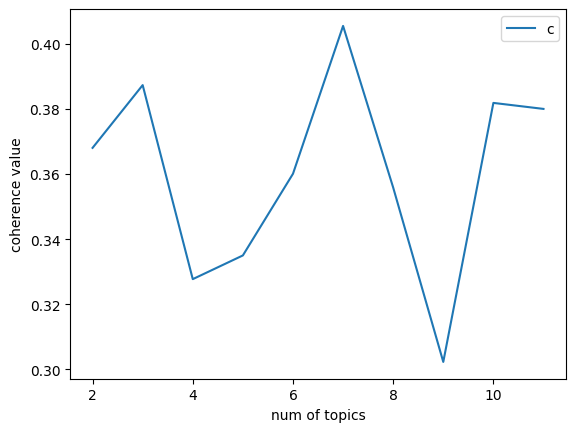

In [18]:
plt.plot(range(min_topics , max_topics+1) , coherence_value)
plt.xlabel("num of topics")
plt.ylabel("coherence value")
plt.legend(("coherence value") ,loc="best")
plt.show()

In [19]:
print(gensim.__version__)

4.3.3
